In [28]:
# 초기 세팅용 import 구문입니다. 먼저 실행한 뒤 실습 코드를 작성합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.impute import SimpleImputer

# 결측치가 포함된 데이터
data = pd.DataFrame({
    "age": [25, None, 27, None, 30],
    "income": [50000, 60000, None, 52000, 58000]
})

# SimpleImputer : 걸측치 전처리기 생성
# strategy="값" : 결측치가 있을 경우 평균, 중앙값, 등의 값을 자동으로 넣는다
imputer = SimpleImputer(strategy="mean")

# fit_XXXXX : fit은 학습
# imputer.fit_transform(data) : data 학습 후 결측치를 mean으로 변환
data_cleared = pd.DataFrame(
    imputer.fit_transform(data),
    columns=data.columns
)
print("기본값")
display(data)
print("결측치(None) 평균값으로 처리")
display(data_cleared)

기본값


,age,income
0,25.0,50000.0
1,NaN,60000.0
2,27.0,NaN
3,NaN,52000.0
4,30.0,58000.0


결측치(None) 평균값으로 처리


,age,income
0,25.000000,50000.0
1,27.333333,60000.0
2,27.000000,55000.0
3,27.333333,52000.0
4,30.000000,58000.0


# Regression(회귀)

- 연속적인 숫자형 데이터를 예측하기 위해 사용되는 머신러닝 모델이다.
- 주어진 입력 변수(특성)와 출력 변수(타겟) 간의 관계를 찾고, 이를 바탕으로 새로운 데이터의 값을 예측하는 것이 목표이다.
- 회귀 모델의 핵심은 연속형 목표 변수를 예측하는 것이며, 이를 통해 실제 값과 예측 값의 차이를 줄이는 방향으로 학습한다.


**회귀 알고리즘 종류**
<table>
    <thead>
        <tr>
            <th>알고리즘</th>
            <th>설명</th>
            <th>특징</th>
            <th>적용 예시</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>K-최근접 이웃 회귀 <code>sklearn.neighbors.KNeighborsRegressor</code></td>
            <td>K개의 이웃의 평균을 사용하여 예측을 수행함.</td>
            <td>간단하고 이해하기 쉬움; K 값에 민감.</td>
            <td>명확한 패턴이 있는 데이터의 빠른 예측.</td>
        </tr>
        <tr>
            <td>선형 회귀 <code>sklearn.linear_model.LinearRegression</code></td>
            <td>두 변수 간의 선형 관계를 모델링함.</td>
            <td>이해하고 구현하기 쉬움; 선형 데이터를 가정함.</td>
            <td>평수를 기반으로 주택 가격 예측.</td>
        </tr>
        <tr>
            <td>다항 회귀 <code>sklearn.preprocessing.PolynomialFeatures</code> + <code>sklearn.linear_model.LinearRegression</code></td>
            <td>비선형 관계를 모델링하기 위해 선형 회귀를 확장함.</td>
            <td>비선형 데이터를 처리; 과대적합 위험이 있음.</td>
            <td>곡선형 패턴 예측.</td>
        </tr>
        <tr>
            <td>릿지 회귀 <code>sklearn.linear_model.Ridge</code></td>
            <td>과대적합을 방지하기 위해 L2 정규화를 사용함.</td>
            <td>모델 복잡도를 줄임; 고차원 데이터에 적합함.</td>
            <td>잡음이 많은 데이터 예측.</td>
        </tr>
        <tr>
            <td>라쏘 회귀 <code>sklearn.linear_model.Lasso</code></td>
            <td>L1 정규화를 적용하여 일부 가중치를 0으로 만듭니다.</td>
            <td>자동으로 변수 선택; 모델 해석성 향상.</td>
            <td>중요한 특성만 남기고 싶을 때.</td>
        </tr>
        <tr>
            <td>엘라스틱넷 회귀 <code>sklearn.linear_model.ElasticNet</code></td>
            <td>릿지와 라쏘를 결합하여 다중공선성을 처리하고 변수 선택을 지원함.</td>
            <td>두 정규화의 장점을 모두 취함; 다목적 사용 가능.</td>
            <td>상관된 특성이 많은 고차원 데이터셋.</td>
        </tr>
        <tr>
            <td>로지스틱 회귀 <code>sklearn.linear_model.LogisticRegression</code></td>
            <td>이진 분류 문제에 사용되며 확률을 예측함.</td>
            <td>0과 1 사이의 확률을 출력; 분류에 특화.</td>
            <td>스팸 메일 분류, 질병 유무 예측.</td>
        </tr>
        <tr>
            <td>서포트 벡터 회귀 <code>sklearn.svm.SVR</code></td>
            <td>SVM을 회귀 문제에 적용하여 마진 오류를 허용함.</td>
            <td>비선형 데이터를 처리; 커널 트릭 사용 가능.</td>
            <td>복잡한 데이터 구조 예측.</td>
        </tr>
        <tr>
            <td>의사결정트리 회귀 <code>sklearn.tree.DecisionTreeRegressor</code></td>
            <td>의사결정트리를 사용하여 데이터를 분할하고 평균을 예측함.</td>
            <td>직관적이고 비선형 관계를 잘 처리; 과대적합 위험.</td>
            <td>복잡한 데이터셋의 회귀 분석.</td>
        </tr>
        <tr>
            <td>랜덤 포레스트 회귀 <code>sklearn.ensemble.RandomForestRegressor</code></td>
            <td>여러 개의 결정 트리를 앙상블하여 정확도를 높임.</td>
            <td>높은 정확도; 과대적합에 강함.</td>
            <td>비선형 관계의 복잡한 예측.</td>
        </tr>
        <tr>
            <td>그래디언트 부스팅 회귀 <code>sklearn.ensemble.GradientBoostingRegressor</code></td>
            <td>약한 예측 모델을 순차적으로 학습하여 강력한 모델을 만듭니다.</td>
            <td>높은 예측 성능; 계산 비용이 큼.</td>
            <td>정밀한 예측이 필요한 대규모 데이터셋.</td>
        </tr>
    </tbody>
</table>

**회귀 구분**
1. 회귀계수의 선형/비선형 여부에 따라
   - 선형회귀
   - 비선형회귀
2. 독립변수/종속변수의 개수에 따라
   - 단일회귀
   - 다중회귀


## 최근접 이웃 회귀
농어 perch의 **길이**가 특성이고 **무게**가 타깃이 된다.

<img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px">


In [2]:
# 초기 세팅용 import 구문입니다. 먼저 실행한 뒤 실습 코드를 작성합니다.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [3]:
# perch_length: 모델이 예측할 때 참고하는 입력값 X임.
# 여기서는 feature가 하나뿐이므로 각 값은 농어 한 마리의 길이를 의미함.
perch_length = np.array([
    8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
    21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
    22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
    27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
    36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
    40.0, 42.0, 43.0, 43.0, 43.5, 44.0])

# perch_weight: 모델이 맞혀야 하는 정답 y임.
# 회귀 문제이므로 target은 Bream/Smelt 같은 클래스가 아니라 연속적인 숫자 무게임.
perch_weight = np.array([
    5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
    110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
    130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
    197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
    514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
    820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
    1000.0, 1000.0])

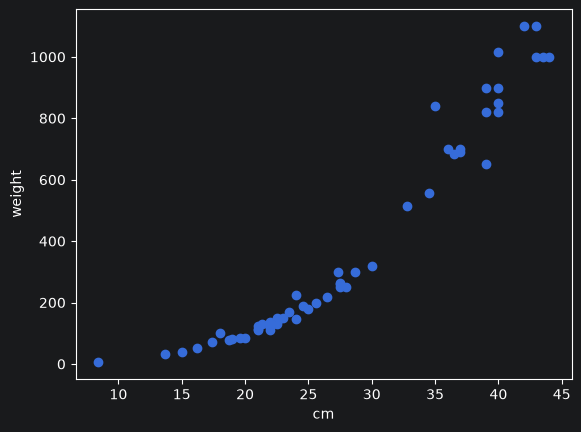

In [4]:
# 길이와 무게의 관계를 산점도로 표시

plt.scatter(perch_length, perch_weight)
plt.xlabel("cm")
plt.ylabel("weight")
plt.show()


### 학습/평가 데이터 분리
- `train_test_split`: 데이터를 학습용과 평가용으로 나누는 함수


In [30]:
from sklearn.model_selection import train_test_split

# 회귀모델은 입력 데이터의 특성을 바탕으로 연속적인 숫자 값을 예측하는 모델입니다.

X_train, X_test, y_train, y_test = train_test_split(
    perch_length,
    perch_weight,
    test_size=0.25,
    random_state=42)

print(X_train.shape, y_train.shape, )
print(X_test.shape, y_test.shape)

# 사이킷런(scikit-learn)에서 제공하는 모델의 입력값 X는 보통 2차원
# 1차원 데이터를 2차원 데이터로 convert
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(42,) (42,)
(14,) (14,)
(42, 1) (42,)
(14, 1) (14,)


### KNeighborsRegressor
- KNN 방식의 회귀 모델
- 새 데이터가 들어오면 가까운 이웃 K개의
- tartget(y값, label) 평균을 구하여 예측값을 사용

In [31]:
# KNN 회구 모델 생성 및 학습
# 회귀모델은 : KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor

# n_neighbors=5:  5개의 인접한 이웃을 찾는다
knn_reg = KNeighborsRegressor(n_neighbors=5)

#학습(fit) -> 평가(score) -> 예측(predict)
knn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


### 결정 계수 ($R^2$)
- 회귀 모델이 정답값의 변화를 얼마나 잘 설명하는지 보는 지표

### $R^2$의 특징
* **범위**: $R^2$ 값은 일반적으로 0에서 1 사이의 값을 가지며, 1에 가까울수록 모델이 데이터를 잘 설명한다는 것을 의미한다. 그러나 일부 모델에서는 음수 값을 가질 수도 있다.
* **높은 $R^2$ 값의 의미**: 높은 $R^2$ 값은 회귀 모델이 독립 변수들을 사용하여 종속 변수의 변동을 잘 설명하고 있다는 것을 나타낸다. 이는 모델이 좋은 피팅을 제공하고 있다는 것을 의미한다.
* **낮은 $R^2$ 값의 의미**: 낮은 $R^2$ 값은 모델이 데이터를 잘 설명하지 못하고 있다는 것을 의미한다. 이는 모델이 중요한 패턴이나 변수들을 놓치고 있다는 것을 시사한다.
---
$$
R^2 = 1 − \frac{\sum\limits_{i=1}^{n}(y_i−\hat{y_i})^2}{\sum\limits_{i=1}^{n}(y_i−\bar{y_i})^2}
$$
* $y\_i$는 실제 값이다.
* $\hat{y\_i}$는 모델이 예측한 값이다.
* $\bar{y\_i}$는 실제 값의 평균이다.
* $\sum\limits\_{i=1}^{n}(y\_i−\hat{y\_i})^2$는 \*\*잔차 제곱합(Sum of Squares of Residuals, SSR)\*\*이라 하며, 모델이 예측한 값과 실제 값 사이의 차이를 나타낸다.
* $\sum\limits\_{i=1}^{n}(y\_i−\bar{y\_i})^2$는 \*\*총 변동합(Total Sum of Squares, SST)\*\*이라 하며, 실제 값의 평균에 대한 변동성을 나타낸다.



In [32]:
# KNN 회구 모델의 학습 성능과 평과 성능

train_socre = knn_reg.score(X_train, y_train)
test_socre = knn_reg.score(X_test, y_test)

print("train_socre: ", train_socre)
print("test_socre: ", test_socre)

# 학습 성능 점수가 테스트 평가 점수보다 지나치게 높으면 과대적합 가능성을 의심

train_socre:  0.9698823289099254
test_socre:  0.992809406101064


In [33]:
# 학습 했고 , 평가했고, 이제 예측
# 예측

# 인접한 이웃을 찾는다
pred = knn_reg.predict(X_test)
print(X_test)
# KNN 회귀 모델로 X_test의 무게를 예측
print(pred)

# 알아보기 쉽게 ','보기위한 리스트 전환
# print(X_test.squeeze().tolist())
# print(pred.tolist())

# (테스트값 - 예측값)^2 값들을 모두 더한 값이 에러
# 모델이 예측한 값과 실제 값 사이의 차이를 나타낸다.
model_error = np.sum((y_test - pred) ** 2)
# 실제 값의 평균에 대한 변동성을 나타낸다.
baseline_error = np.sum((y_test - np.mean(y_test)) ** 2)
result = 1 - (model_error / baseline_error)
print("R^2: ", result)


[[ 8.4]
 [18. ]
 [27.5]
 [21.3]
 [22.5]
 [40. ]
 [30. ]
 [24.6]
 [39. ]
 [21. ]
 [43.5]
 [16.2]
 [28. ]
 [27.3]]
[  60.    79.6  248.   122.   136.   847.   311.4  183.4  847.   113.
 1010.    60.   248.   248. ]
R^2:  0.992809406101064


In [34]:
# 테스트 데이터 3개만 이용해서 입력값, 예측값, 실제값 비교

# predict : 예측값
pred2 = knn_reg.predict(X_test[:3])  # 슬라이싱 0,1,2행
# pred2
print("입력값 :", X_test[:3])
print("예측값 :", pred2)
print("실제값 :", y_test[:3])


입력값 : [[ 8.4]
 [18. ]
 [27.5]]
예측값 : [ 60.   79.6 248. ]
실제값 : [  5.9 100.  250. ]


### 최적의 최근접 이웃 개수 찾기


/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50883 (\N{HANGUL SYLLABLE US}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/choejiheum/miniforge3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46412 (\N{HANGUL SYLLABLE DDAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


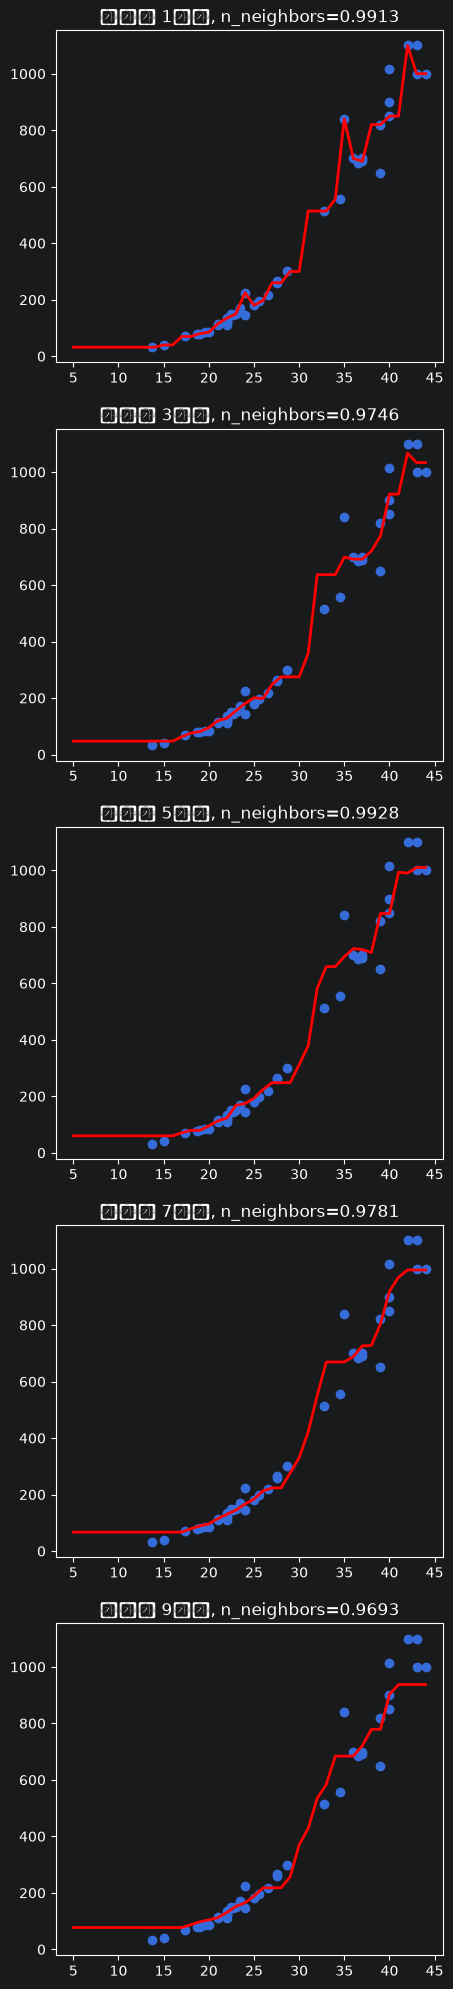

In [35]:
# n_neighbors의 값을 바꿔가며 예측선이 어떻게 바뀌는지 확인한다

n_neighbors = [1, 3, 5, 7, 9]
# 예측선의 x축 좌표를 담당할 배열 생성
x = np.arange(5, 45).reshape(-1, 1)

plt.figure(figsize=(5, 25))

# 이웃 숫자를 바꿔가며 모델 순서 및 그래프 출력
for i, n in enumerate(n_neighbors):
    # 모델 생성
    knn_reg = KNeighborsRegressor(n_neighbors=n)
    # 학습
    knn_reg.fit(X_train, y_train)
    # 평가 (회귀 모델의 평가는 R^2 결정 계수를 이용한다)
    r_squared = knn_reg.score(X_test, y_test)
    # # 예측
    # r_squared_pred = knn_reg.predict(r_squared)
    # 5행 1열의 서브플롯(subplot)이 있고 그중에 i+1번째
    plt.subplot(5, 1, i + 1)

    # 실제 학습 데이터 점선분포도를 그린다
    plt.scatter(X_train, y_train)
    # 농어길이 5~44 범위에 대해 KNN 회귀 모델이 예측한 무게를 그린다
    plt.plot(x, knn_reg.predict(x), color="red", linewidth=2)
    plt.title(f'이웃이 {n}일때, n_neighbors={r_squared:.4f}')

plt.show()

근접한 이웃은 예측하려는 데이터와 특성값이 가장 비슷한 기존 데이터를 말합니다.

예를 들어 집값 예측이라면:
면적 30평, 방 3개, 역까지 5분
이 집과 비슷한 조건의 기존 집들이 “근접한 이웃”입니다.
KNN은 그 이웃들의 값을 보고 새 데이터의 값을 예측합니다.

회귀에서는 보통 이렇게 봅니다.
가까운 이웃 3개의 집값:
5억, 5.2억, 4.8억
예측값 = 평균 = 5억

n_neighbors를 바꾸는 이유는 몇 개의 이웃을 참고할지에 따라 예측 결과가 달라지기 때문입니다.

- n=1: 가장 가까운 데이터 1개만 봄
→ 민감함, 튀는 값에 흔들릴 수 있음

- n=3, n=5: 가까운 여러 개의 평균을 봄
→ 좀 더 안정적

- n이 너무 큼: 너무 많은 데이터를 평균냄
→ 가까운 데이터의 특징이 흐려져서 예측이 둔해짐

즉, n을 바꿔보는 이유는 너무 예민하지도 않고, 너무 둔하지도 않은 적절한 이웃 수를 찾기 위해서입니다.

## KNN (최근접이웃) 모델의 한계
- KNN은 범위 밖의 추세를 새로 계산하지 못하고, 가장 가까운 기존 이웃들의 평균으로만 예측함.


## 결과 확인

## 선형 회귀
**`sklearn.linear_model.LinearRegression`**
- 머신러닝에서 가장 기본적이고 널리 사용되는 지도 학습 알고리즘 중 하나
- 연속적인 숫자 값을 예측하는 데 사용되며, 독립 변수(입력 변수)와 종속 변수(출력 변수) 사이의 관계를 선형 방정식으로 나타낸다.
-  즉, 데이터가 직선이나 평면으로 표현될 수 있다고 가정
- 선형 회귀의 목표는 주어진 데이터에 가장 잘 맞는 직선(또는 초평면)을 찾아 새로운 입력 값에 대한 예측을 수행하는 것이다.

---

1. **`coef_` (회귀 계수, w)**:
   - `coef_`는 학습된 선형 회귀 모델의 각 특성(feature)에 대한 가중치(weight) 또는 회귀 계수(coefficient)이다.
   - 선형 회귀 모델의 방정식은 다음과 같은 형태로 표현된다:
   $$
   y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
   $$
   여기서 $w_1, w_2, \dots, w_n$이 각각의 특성에 대한 회귀 계수이고, 이 값이 바로 `coef_`에 해당한다. 즉, `coef_`는 특성 $x$에 대한 선형 관계에서 기울기를 나타낸다.
   - `coef_`의 크기와 부호는 각 특성이 종속 변수 $y$에 미치는 영향을 나타낸다:
     - **양수**이면, 해당 특성 값이 증가할 때 $y$도 증가한다.
     - **음수**이면, 해당 특성 값이 증가할 때 $y$는 감소한다.
     - **0**이면, 해당 특성은 $y$에 영향을 미치지 않는다.
2. **`intercept_` (절편, b)**:
   - `intercept_`는 회귀 직선이 y축을 교차하는 점을 의미하는 절편 값이다.
   - 선형 회귀 방정식에서 절편 $b$에 해당하는 값으로, 독립 변수 $x_1, x_2, \dots, x_n$가 모두 0일 때 종속 변수 $y$의 예측 값이다.
   $$
   y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
   $$


## 선형 회귀 모델을 이용한 KNN 외삽 한계 보완
---
#### LinearRegression(): 입력 X와 정답 y 사이의 직선 관계를 학습하는 회귀 모델임.
- 단일 feature에서는 y = w * x + b 형태의 기울기 w와 절편 b를 찾음.
- 다중 feature에서는 y = w_1 * x_1 + w_2 * x_2 + ... + w_n * x_n + b 형태의 기울기 w와 절편 b를 찾음.
| 용어 | 의미 | 예시 해석 |
|---|---|---|
| 기울기 | `x`가 1 증가할 때 `y`가 얼마나 변하는지 나타내는 값 | 길이가 1cm 늘 때 무게가 몇 g 늘어나는지 |
| 회귀계수 | feature에 곱해지는 값. 기울기와 거의 같은 의미로 사용됨 | `w` |
| 절편 | `x`가 0일 때의 예측값 | `b` |


## 결과 확인

# 특성 공학 Feature engineering
- 특성 공학은 모델이 데이터를 더 잘 이해하고 예측할 수 있도록 입력 feature를 만들고, 고치고, 정리하는 과정임.
- 머신러닝 모델은 사람이 보는 “의미”를 바로 이해하지 못하고 숫자 패턴만 봄.
- 그래서 원본 데이터를 그대로 넣기보다, 문제에 맞게 feature를 가공해주면 성능이 좋아질 수 있음.

---
1. 특성 생성
    - 파생/요약변수 생성
    - 다항 특성 생성: 비선형 데이터를 처리하기위해서, 기존변수의 차수를 추가한 변수를 생성
2. 특성 변환
3. 차원 축소
4. 중복값/결측치 처리


## 농어 데이터 로드
- 길이, 높이, 너비를 함께 사용하는 다중 feature 농어 데이터를 불러옴.
    - 기존에는 농어의 길이 하나만 feature로 사용함.
    - 이번에는 길이, 높이, 너비를 함께 사용해 입력 정보를 늘림.
    - 이처럼 모델이 참고할 정보를 추가하거나 새 feature를 만드는 과정이 특성 공학임.


### DataFrame의 컬럼명을 확인해 feature와 target을 정확히 선택할 준비


### 학습/평가 데이터 분리

- 길이, 높이, 너비 3개 feature를 X로 만들고 무게를 y로 만든 뒤 학습/평가 데이터로 나눔.


## 모델 학습


## 모델 예측

## 결과 확인

## 다항 특성 생성 Polynomial Feature
- `PolynomialFeatures(degree=2)`: 2차항까지 feature를 확장함.
- 기존 feature를 어떤 다항 feature로 확장하는지 확인함.

### 다항 특성을 생성하는 이유
- 현실에서는 농어 무게가 길이, 높이, 너비와 완전히 직선 관계가 아닐 수 있음
- 예를 들어 생선이 길어질수록 무게는 단순히 일정하게 증가하기보다 더 빠르게 증가할 수 있음.
- 이때 다항 feature를 추가하면 아래 처럼 계산이 가능해, 곡선적인 관계를 표현할 수 있음
```
weight = w1*length
       + w2*height
       + w3*width
       + w4*length²
       + w5*length*height
       + ...
       + b
```


### 농어의 3개 feature를 2차 다항 feature로 확장


### 5차 다항 feature를 사용해 모델 복잡도가 커졌을 때 과대적합 가능성을 확인


## 과대적합 | 과소적합
![](https://d.pr/i/4j93wE+)
https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html
**과대적합 (Overfitting)**
- 모델이 훈련 데이터에 너무 맞춰져서 새로운 데이터에 일반화되지 않는 상태.
- 데이터에서는 높은 정확도를 보이지만 테스트 데이터에서는 성능이 떨어짐.
- 데이터의 잡음(noise)까지 학습하여 복잡한 패턴을 모방함.
- 데이터의 각 샘플을 완벽하게 분류하지만, 새로운 데이터에 대해 잘못된 예측을 많이 함.
- 해결 방법:
  - 모델 단순화: 복잡도를 줄여 모델을 간단하게 만듦.
  - 정규화: L1, L2 정규화를 통해 모델의 복잡도를 줄임.
  - 더 많은 데이터: 훈련 데이터를 더 많이 수집하여 모델의 일반화 능력을 향상시킴.
  - 드롭아웃: 신경망의 경우 일부 뉴런을 임의로 제외하여 학습하는 드롭아웃 기법을 사용함.
**과소적합 (Underfitting)**
- 모델이 훈련 데이터와 테스트 데이터 모두에서 제대로 학습하지 못한 상태.
- 훈련 데이터에서도 낮은 정확도를 보임.
- 너무 단순한 모델로 인해 데이터의 패턴을 잡아내지 못함.
- 데이터의 중요한 특징을 무시하여 전반적인 성능이 낮음.
- 해결 방법:
  - 모델 복잡화: 더 복잡한 모델을 사용하거나 더 많은 특성을 추가하여 학습 능력을 높임.
  - 특성 공학: 데이터의 중요한 특징을 잘 반영할 수 있도록 특성을 추가하거나 변환함.
  - 더 긴 학습 시간: 학습 과정을 더 오래 진행하여 모델이 데이터를 더 잘 이해하게 함.
**예시로 설명하기**
- 과대적합 예시:
  - 학생이 시험 공부할 때, 기출문제의 답만 외우고 시험에 나올 다른 문제 유형을 대비하지 않는 것과 비슷함. 기출문제에서는 높은 점수를 받지만 새로운 문제에서는 낮은 점수를 받습니다.
  - 그래프로 시각화해보면 훈련 데이터에 정확히 맞는 복잡한 곡선을 그리는 모델. 새로운 데이터에 대해 일반화되지 못함.
- 과소적합 예시:
  - 학생이 시험 공부를 충분히 하지 않아, 기본적인 개념조차 이해하지 못하는 경우임. 따라서 기출문제와 시험 모두에서 낮은 점수를 받습니다.
  - 그래프로 시각화해보면 단순한 직선이나 곡선을 그리는 모델. 데이터의 패턴을 잘 잡아내지 못함.


## 길이 하나만 사용하던 데이터를 2차 다항 feature로 바꿔 곡선 회귀 실습


## 데이터 변환

- fit_transform: 기준 학습과 변환을 한 번에 수행하는 메서드임.
- predict: 학습된 모델로 새 데이터의 예측값을 생성하는 메서드임.
